<i>## Comments will be provided using this format. Key takeaway: groups are encouraged to change the formatting, but not the structure. Groups are also allowed to create additional notebooks - for instance, create one notebook for data exploration, and one notebook for each preprocessing-modelling-evaluation pipeline -, but must strive to keep an unified style across notebooks.</i>

#### NOVA IMS / BSc in Data Science / Text Mining 2025/2026
### <b>Group Project: "Straining the great southern Melting Pot"</b>
#### Notebook `Notebook Title`

#### Group:
- Cyrine Moalla - 20230003
- Khadija Belhamra - 20230007
- Victoriya Mokhovikova - 20230796
- Vlad Botnev - 20230795

#### <font color='#BFD72'>Table of Contents </font> <a class="anchor" id='toc'></a> 
- [1. Data Understanding](#P1)
- [2. General Data Preparation](#P2) 
- [3. Multilabel Classification (Information Requirement 3311)](#P3)
    - [3.1 Specific Data Preparation](#P31)
    - [3.2 Model Implementation](#P32)
    - [3.3 Model Evaluation](#P3n)
- [4. Sentiment Analysis (Information Requirement 3312)](#P4)
    - [4.1 Specific Data Preparation](#P41)
    - [4.2 Model Implementation](#P42)
    - [4.3 Model Evaluation](#P43)
- [...]
- [N. Additional Tasks (Information Requirements 332n)](#Pn)
    - [N.1 Specific Data Preparation](#Pn1)
    - [N.2 Model Implementation](#Pn2)
    - [N.3 Model Evaluation](#Pn3)

<i>## Note that the notebook structure differs from the report: instead of following the CRISP-DM phases and then specifying the different problems inside the phases, the notebook is structured by problem, with the CRISP-DM phases being defined for each specific problem.

<font color='#BFD72F' size=5>1. Imports</font> <a class="anchor" id="P1"></a>

In [1]:
# General-Purpose Libraries
import os
import regex as re
import time
import unicodedata
import numpy as np
import pandas as pd
import math

# Text Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer
import html
import unicodedata
import emoji

nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import networkx as nx


# Text Analysis
from collections import Counter
from nltk.util import ngrams
from textblob import TextBlob
from itertools import combinations


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/vlbotnev/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vlbotnev/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/vlbotnev/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


<font color='#BFD72F' size=5>1. Data Understanding</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)


In [2]:
atlanta_rest = pd.read_csv("data_atlanta/atlanta_restaurant_slice_2023.csv", header=0)
atlanta_rest

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...
...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Friday night dinner was Chicken Francaise. Jor...
53562,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Great dinner.... Yay Jordan!!!!!!
53563,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was our server and he was fantastic! Gr...
53564,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was an amazing server! Great delicious...


In [3]:
atlanta_rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


In [4]:
# Drop the unneeded columns, rename the 'text' column to 'raw_text', and change its data type to 'string'.
atlanta_rest = atlanta_rest.drop(columns=["website", "url"])
atlanta_rest = atlanta_rest.rename(columns={"text": "raw_content"})
atlanta_rest["raw_content"] = atlanta_rest["raw_content"].astype(str)
atlanta_rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   reviewsCount  53566 non-null  int64  
 3   stars         53566 non-null  float64
 4   raw_content   53566 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 2.0+ MB


In [5]:
atlanta_rest["categoryName"].value_counts()

categoryName
Mexican restaurant          8959
Fast food restaurant        5325
Italian restaurant          5108
American restaurant         5049
Pizza restaurant            4560
Breakfast restaurant        2491
Chinese restaurant          2484
Seafood restaurant          2048
Hamburger restaurant        1979
New American restaurant     1903
Sandwich shop               1862
Chicken restaurant          1780
Steak house                 1776
Indian restaurant           1753
Japanese restaurant         1533
Mediterranean restaurant    1450
Thai restaurant             1260
Barbecue restaurant         1139
Bar & grill                 1107
Name: count, dtype: int64

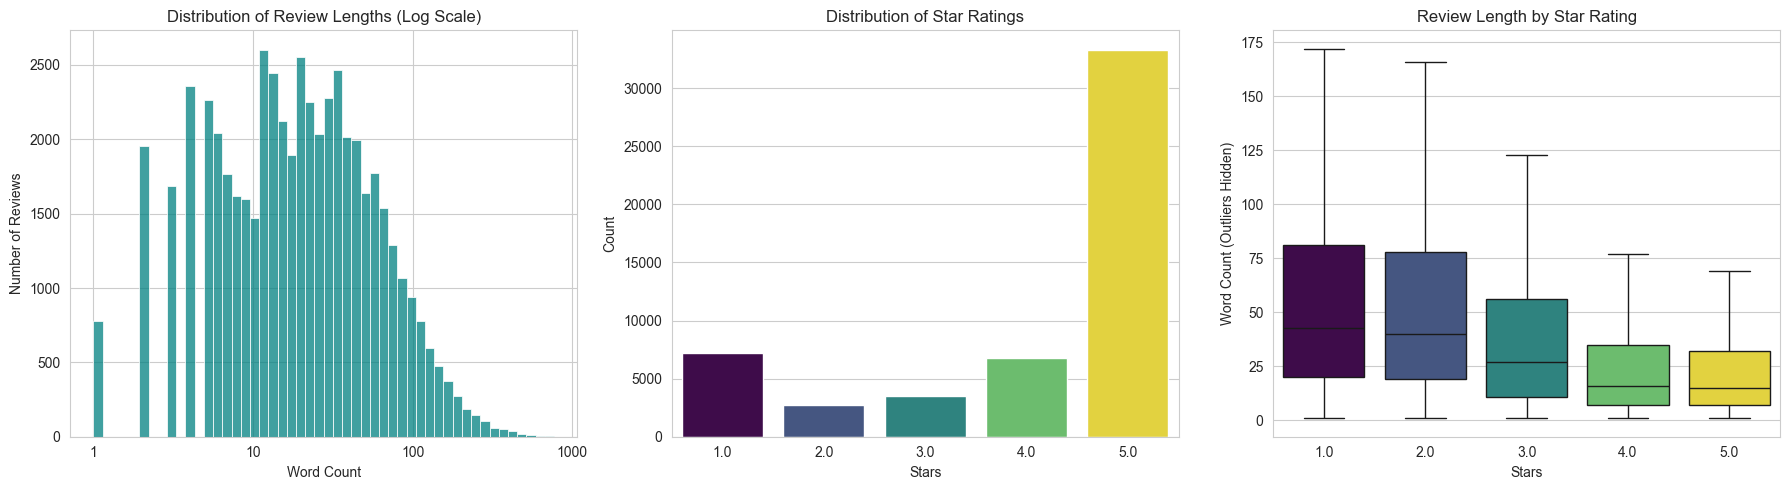

=== Descriptive Statistics: Word Counts ===


,count,mean,std,min,25%,50%,75%,max
word_count,53566.0,33.454542,44.610324,1.0,8.0,19.0,41.0,768.0



=== Class Balance: Stars ===


stars,1.0,2.0,3.0,4.0,5.0
Share of Total,0.134302,0.051133,0.065975,0.126946,0.621644


In [6]:
sns.set_style("whitegrid")

atlanta_rest["word_count"] = atlanta_rest["raw_content"].str.split().str.len()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of Review Lengths
sns.histplot(
    atlanta_rest["word_count"], bins=50, log_scale=True, ax=axes[0], color="teal"
)

axes[0].set_title("Distribution of Review Lengths (Log Scale)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Number of Reviews")

# Manually set ticks to improve readability on log scale
axes[0].set_xticks([1, 10, 100, 1000])
axes[0].get_xaxis().set_major_formatter(ticker.ScalarFormatter())
axes[0].minorticks_off()

# Star Rating Distribution
sns.countplot(
    x="stars",
    hue="stars",
    data=atlanta_rest,
    palette="viridis",
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Distribution of Star Ratings")
axes[1].set_xlabel("Stars")
axes[1].set_ylabel("Count")

# Relationship between Stars and Review Length
sns.boxplot(
    x="stars",
    y="word_count",
    hue="stars",
    data=atlanta_rest,
    showfliers=False,
    palette="viridis",
    legend=False,
    ax=axes[2],
)

axes[2].set_title("Review Length by Star Rating")
axes[2].set_xlabel("Stars")
axes[2].set_ylabel("Word Count (Outliers Hidden)")

plt.tight_layout()
plt.show()

print("=== Descriptive Statistics: Word Counts ===")
display(atlanta_rest["word_count"].describe().to_frame().T)

print("\n=== Class Balance: Stars ===")
display(
    atlanta_rest["stars"]
    .value_counts(normalize=True)
    .sort_index()
    .to_frame(name="Share of Total")
    .T
)


In [7]:
# Define thresholds for inspection
SHORT_THRESHOLD = 3
LONG_THRESHOLD = 500

short_reviews = atlanta_rest[atlanta_rest["word_count"] <= SHORT_THRESHOLD]
long_reviews = atlanta_rest[atlanta_rest["word_count"] >= LONG_THRESHOLD]

print(f"=== Extreme Value Analysis ===\n")
print(f"Extremely Short Reviews (<= {SHORT_THRESHOLD} words): {len(short_reviews)}")
print(f"Extremely Long Reviews (>= {LONG_THRESHOLD} words): {len(long_reviews)}")

print("\n--- Examples: Too Short (Potential Noise) ---")
if not short_reviews.empty:
    display(
        short_reviews[["stars", "raw_content"]].sample(
            min(5, len(short_reviews)), random_state=42
        )
    )

print("\n--- Examples: Too Long (Potential Truncation Risk) ---")
if not long_reviews.empty:
    # Show only first 200 chars to save space
    long_sample = (
        long_reviews[["stars", "raw_content"]]
        .sample(min(3, len(long_reviews)), random_state=42)
        .copy()
    )
    long_sample["raw_content"] = long_sample["raw_content"].apply(
        lambda x: x[:200] + "..."
    )
    display(long_sample)

=== Extreme Value Analysis ===

Extremely Short Reviews (<= 3 words): 4420
Extremely Long Reviews (>= 500 words): 28

--- Examples: Too Short (Potential Noise) ---


,stars,raw_content
15604,5.0,Awesome pizza!
18629,4.0,Clean and polite.
24907,5.0,Jamesina was great
24621,5.0,Amazing chicken wing
50200,5.0,Great job Adriana!



--- Examples: Too Long (Potential Truncation Risk) ---


,stars,raw_content
15101,1.0,"Every time I place an order online, I have pro..."
51288,3.0,"Aw man, I really wanted this to be 5 stars but..."
14036,1.0,HORRIBLE Experience HORRIBLE Owner\n\nI was so...


In [8]:
# Ensure word_count is calculated
if "word_count" not in atlanta_rest.columns:
    atlanta_rest["word_count"] = atlanta_rest["raw_content"].str.split().str.len()

# 1. Pearson Correlation (Linear relationship)
pearson_corr = atlanta_rest["stars"].corr(atlanta_rest["word_count"], method="pearson")

# 2. Spearman Correlation (Monotonic relationship - better for non-normal data/ranks)
spearman_corr = atlanta_rest["stars"].corr(
    atlanta_rest["word_count"], method="spearman"
)

print(f"=== Correlation Analysis: Stars vs. Review Length ===\n")
print(f"Pearson Correlation (r):   {pearson_corr:.4f}")
print(f"Spearman Correlation (ρ):  {spearman_corr:.4f}")

# Interpretation logic for the report
if spearman_corr < 0:
    print("\nInsight: Negative correlation detected.")
    print("Lower ratings tend to have longer reviews (people rant more when angry).")
elif spearman_corr > 0:
    print("\nInsight: Positive correlation detected.")
    print("Higher ratings tend to have longer reviews.")
else:
    print("\nInsight: No significant correlation found.")

=== Correlation Analysis: Stars vs. Review Length ===

Pearson Correlation (r):   -0.3086
Spearman Correlation (ρ):  -0.2878

Insight: Negative correlation detected.
Lower ratings tend to have longer reviews (people rant more when angry).


In [9]:
atlanta_rest["raw_content"].sample(5)

15502    Very authentic! Incrediblly different and fasc...
17348    Again, Normally go to the Duluth location but ...
52464    Twisted kitchen is our favorite restaurant to ...
2042     Wonderful meal and our server Jodie was incred...
37371                              Alaysha was fantastic!!
Name: raw_content, dtype: object

In [10]:
(atlanta_rest.groupby("title")["categoryName"].nunique().loc[lambda x: x > 1])


title
J. Christopher's    2
Name: categoryName, dtype: int64

In [11]:
jc = atlanta_rest[atlanta_rest["title"] == "J. Christopher's"]

print("Rows:", len(jc))
print("Unique reviews:", jc["raw_content"].nunique())
print("Categories:", jc["categoryName"].unique())


Rows: 389
Unique reviews: 386
Categories: ['Breakfast restaurant' 'American restaurant']


In [12]:
s = atlanta_rest["raw_content"].astype(str)

# Define regex patterns for Data Understanding
PATTERNS = {
    # 1. Rare Typography: Detects em-dashes, en-dashes, ellipses, and bullets.
    # These often require normalization (e.g., replacing '…' with '...') for standard tokenizers.
    "typography_special": re.compile(r"[\u2012-\u2015\u2026\u2022]"),
    # 2. Non-Latin Scripts: Detects any letter character that is NOT from the Latin script.
    # This effectively captures Cyrillic, Hebrew, Han (Chinese/Japanese), Arabic, etc.
    "non_latin_scripts": re.compile(r"(?!\p{Latin})\p{L}"),
    # 3. Latin Diacritics: Detects Latin characters outside the ASCII range (e.g., é, ñ, ü).
    # Useful for distinguishing between foreign languages (Spanish) and loanwords in English (café).
    "latin_diacritics": re.compile(r"(?=\p{Latin})[^\x00-\x7F]"),
    # 4. Visual Emojis: Detects standard pictographic emojis.
    "emojis_visual": re.compile(r"\p{Extended_Pictographic}"),
    # 5. Technical/Invisible Characters: Detects non-printable or control characters.
    # Includes Non-breaking space (\u00A0), Zero-width chars (\u200B-\u200F),
    # Variation Selectors (\uFE0F), and Byte Order Marks (\uFEFF).
    "technical_invisible": re.compile(r"[\u00A0\u200B-\u200F\uFE0F\uFEFF]"),
}

print("Regex patterns compiled successfully.")

Regex patterns compiled successfully.


In [13]:
# Apply patterns to the dataset to create boolean masks
results = {}
for name, pat in PATTERNS.items():
    mask = s.apply(lambda x: bool(pat.search(x)))
    results[name] = {
        "affected_reviews": mask.sum(),
        "percentage": f"{(mask.mean() * 100):.2f}%",
    }

# Create a summary DataFrame
stats_df = pd.DataFrame(results).T.sort_values("affected_reviews", ascending=False)

print("=== Corpus Auditing: Review-Level Statistics ===")
display(stats_df)

=== Corpus Auditing: Review-Level Statistics ===


,affected_reviews,percentage
typography_special,802,1.50%
latin_diacritics,691,1.29%
emojis_visual,397,0.74%
technical_invisible,332,0.62%
non_latin_scripts,48,0.09%


In [14]:
# specific code points to audit
INVISIBLE_CHARS = {
    "\u00a0": "NBSP (Non-breaking space)",
    "\u200d": "ZWJ (Zero Width Joiner)",
    "\ufe0f": "VS16 (Variation Selector-16)",
    "\u200b": "ZWSP (Zero Width Space)",
    "\ufeff": "BOM (Byte Order Mark)",
}

audit_data = []

for char_code, desc in INVISIBLE_CHARS.items():
    # Count total occurrences across the entire corpus
    total_count = s.str.count(char_code).sum()

    # Count how many documents contain at least one instance
    docs_affected = s.str.contains(char_code, regex=False).sum()

    if total_count > 0:
        audit_data.append(
            {
                "code_point": f"U+{ord(char_code):04X}",
                "description": desc,
                "total_occurrences": total_count,
                "documents_affected": docs_affected,
            }
        )

audit_df = pd.DataFrame(audit_data).sort_values("total_occurrences", ascending=False)

print("=== Technical Character Audit (Granular) ===")
display(audit_df)

=== Technical Character Audit (Granular) ===


,code_point,description,total_occurrences,documents_affected
2,U+FE0F,VS16 (Variation Selector-16),492,315
1,U+200D,ZWJ (Zero Width Joiner),81,70
0,U+00A0,NBSP (Non-breaking space),45,10
3,U+200B,ZWSP (Zero Width Space),2,2


In [15]:
def inspect_pattern_matches(mask_name, title, n=5):
    """
    Filters the dataset using the defined regex pattern and prints full examples
    for qualitative analysis.
    """
    pat = PATTERNS[mask_name]
    # Filter dataset
    mask = s.apply(lambda x: bool(pat.search(x)))
    subset = atlanta_rest[mask]

    print(f"\n{'=' * 80}")
    print(f"CATEGORY: {title}")
    print(f"Total Matches: {len(subset)}")
    print(f"{'=' * 80}\n")

    if len(subset) > 0:
        # Sample n reviews (random_state fixed for reproducibility in report)
        sample_size = min(n, len(subset))
        examples = subset.sample(sample_size, random_state=42)

        for idx, row in examples.iterrows():
            text = row["raw_content"]
            # Extract distinct matches found in this specific review
            matches = set(pat.findall(text))

            print(f"Row Index: {idx}")
            print(f"Detected Tokens: {matches}")
            print(f"Full Text:\n{text}")
            print("-" * 80)


# 1. Inspect Non-Latin Scripts (to decide on language filtering)
inspect_pattern_matches(
    "non_latin_scripts", "Non-Latin Scripts (Potential Language Outliers)", n=5
)

# 2. Inspect Latin Diacritics (to differentiate Spanish vs. Loanwords)
inspect_pattern_matches("latin_diacritics", "Latin Diacritics", n=5)

# 3. Inspect Typography (to assess tokenization risks)
inspect_pattern_matches(
    "typography_special", "Rare Typography (Dashes, Bullets, Ellipses)", n=5
)

# 4. Inspect Technical Characters (to justify cleaning)
inspect_pattern_matches("technical_invisible", "Invisible & Technical Characters", n=5)


CATEGORY: Non-Latin Scripts (Potential Language Outliers)
Total Matches: 48

Row Index: 26911
Detected Tokens: {'א', 'ע', 'צ', 'כ', 'מ', 'ת', 'ו', 'ל', 'ה'}
Full Text:
אוכל מעולה צוות מעולה
--------------------------------------------------------------------------------
Row Index: 41202
Detected Tokens: {'ω'}
Full Text:
I have been eating at Mr. Fuji for around 5 years now and I have to say. Every single time I have been here it has been such a nice experience.

Mr. Fuji has such a wonderful atmosphere. There is Japanese  art on the walls and the employees are so kind. The owner is very nice and sweet. ♡(.◜ω◝.)♡

The food is amazing. Everything is so authentic, especially the sushi. My favorite is the Volcano roll, I recommend it to anyone who is new to sushi. The food always comes out hot, fresh and delicious!

Overall 5/5 stars
--------------------------------------------------------------------------------
Row Index: 22405
Detected Tokens: {'텝', '음', '친', '션', '수', '펙', '갈', '있', '

We have 19 different types of cuisine

<font color='#BFD72F' size=5>2. Data Preprocessing</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)

<i>## Use markdown cells to describe the purpose of the code cells that follow them.</i>

## 2.1 General Data Cleaning

In [16]:
pat_non_latin = PATTERNS["non_latin_scripts"]

spanish_stopwords = [
    "muy",
    "gracias",
    "pero",
    "bueno",
    "buena",
    "comida",
    "excelente",
    "servicio",
    "lugar",
    "para",
    "estoy",
    "todo",
    "bien",
    "mal",
    "nunca",
    "siempre",
    "delicioso",
    "amigos",
    "familia",
]
pat_spanish_vocab = re.compile(
    r"\b(" + "|".join(spanish_stopwords) + r")\b", re.IGNORECASE
)
pat_spanish_punct = re.compile(r"[¿¡]")

pat_german_chars = re.compile(r"[ßäöüÄÖÜ]")

raw_s = atlanta_rest["raw_content"].astype(str)

mask_non_latin = raw_s.apply(lambda x: bool(pat_non_latin.search(x)))
mask_spanish_vocab = raw_s.apply(lambda x: bool(pat_spanish_vocab.search(x)))
mask_spanish_punct = raw_s.apply(lambda x: bool(pat_spanish_punct.search(x)))
mask_german = raw_s.apply(lambda x: bool(pat_german_chars.search(x)))

mask_to_drop = mask_non_latin | mask_spanish_vocab | mask_spanish_punct | mask_german

print(f"=== Filtering Report ===")
print(f"Non-Latin Scripts detected: {mask_non_latin.sum()}")
print(f"Spanish Vocabulary detected: {mask_spanish_vocab.sum()}")
print(f"Spanish Punctuation detected: {mask_spanish_punct.sum()}")
print(f"German Characters detected: {mask_german.sum()}")
print(f"{'-' * 30}")
print(
    f"TOTAL Reviews to Drop: {mask_to_drop.sum()} ({(mask_to_drop.mean() * 100):.2f}%)"
)

print("\n--- Examples of Dropped Reviews ---")
dropped_df = atlanta_rest[mask_to_drop]
if not dropped_df.empty:
    for i, row in dropped_df.sample(
        min(5, len(dropped_df)), random_state=42
    ).iterrows():
        print(f"[{i}] {row['raw_content'][:150]}...")

initial_len = len(atlanta_rest)
atlanta_rest.drop(atlanta_rest[mask_to_drop].index, inplace=True)
print(
    f"\nDropped {initial_len - len(atlanta_rest)} rows.  Dataset Size: {len(atlanta_rest)}"
)

# Remove duplicate reviews
initial_len_with_duplicates = len(atlanta_rest)
atlanta_rest.drop_duplicates(subset=["raw_content"], inplace=True)
print(
    f"\nDropped {initial_len_with_duplicates - len(atlanta_rest)} duplicated rows. Dataset Size: {len(atlanta_rest)}"
)

=== Filtering Report ===
Non-Latin Scripts detected: 48
Spanish Vocabulary detected: 907
Spanish Punctuation detected: 11
German Characters detected: 11
------------------------------
TOTAL Reviews to Drop: 974 (1.82%)

--- Examples of Dropped Reviews ---
[14340] Waffle House es un excelente lugar para desayunar en familia  un servicio muy bueno y su comida es excelente bien elaborada se lo recomiendo que vayan...
[31412] Mucho Bueno good food...
[11639] Excelente atención. Y la comida riquísima...
[26197] Primero que nada felicidades al nuevo dueño, desde el momento que abres la puerta se siente la hospitalidad, me encanta la decoracion no es el tipico ...
[3764] Muy mal Servicio a parte la actitud de las meseras es muy mal muy mal deberían de cambiar eso y la comida esta del 10 le doy un 2...

Dropped 974 rows.  Dataset Size: 52592

Dropped 1945 duplicated rows. Dataset Size: 50647


In [17]:
def clean_text_pipeline(text):
    """
    Performs data cleaning on raw text reviews.

    Steps:
    1. Handle non-string inputs.
    2. Remove emojis explicitly using the emoji library.
    3. Unescape HTML entities.
    4. Normalize Unicode characters (NFKC).
    5. Standardize punctuation marks (quotes, dashes).
    6. Remove decomposition characters (accents) via NFD normalization.
    7. Lowercase and strip whitespace.

    Args:
        text (str): The raw review text.

    Returns:
        str: The cleaned, normalized text string.
    """
    if not isinstance(text, str):
        return str(text)

    # Remove emojis first to prevent them from being broken into meaningless characters during normalization
    text = emoji.replace_emoji(text, replace="")

    # Standard cleaning steps
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"[\u2018\u2019\u0060\u00B4]", "'", text)
    text = re.sub(r"[\u2012-\u2015]", " - ", text)
    text = text.replace("\u2026", "...")
    text = text.replace("\u2022", " ")
    text = re.sub(r"[\u00A0\u200B-\u200F\uFE0F\uFEFF]", " ", text)

    # Remove accents/diacritics
    text = "".join(
        c for c in unicodedata.normalize("NFD", text) if unicodedata.category(c) != "Mn"
    )

    return re.sub(r"\s+", " ", text).strip().lower()

In [18]:
atlanta_rest["clean_text"] = atlanta_rest["raw_content"].apply(clean_text_pipeline)

In [19]:
CONTRACTION_MAP = {
    "ain't": "is not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so is",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have",
}


pat_contractions = re.compile(r"\b(" + "|".join(CONTRACTION_MAP.keys()) + r")\b")

In [20]:
def expand_contractions(text):
    def replace(match):
        return CONTRACTION_MAP[match.group(0)]

    return pat_contractions.sub(replace, text)

In [21]:
atlanta_rest["clean_text"] = atlanta_rest["clean_text"].apply(expand_contractions)

print("Contractions expanded (e.g., 'didn't' -> 'did not').")
print(
    "Sample check:",
    atlanta_rest.loc[
        atlanta_rest["raw_content"].str.contains("didn't", na=False), "clean_text"
    ]
    .head(1)
    .values,
)

Contractions expanded (e.g., 'didn't' -> 'did not').
Sample check: ["we had a great experience it was my hubby's birthday!! simple things make an experience amazing! we entered seated within 1 minute upon entry the vibe is very cool casual! seated and we notice in our menu it said happy birthday which was super sweet! also the hostesses were very kind and acknowledged that note on the reservation. our server kazhan b was nothing short of amazing! from our menu selections he gave us a dinning experience! we trusted his word with our selections and he did not fail at all. we had oysters to start, octopus, the ga peach salad, entrees , tuna and swordfish and the potatoes, yummy! kazhan adviced me to get the reddish, but i went with swordfish( it was a but dry, im guessing from the confit). dessert was delicious and they were kind enought to make my hubby birthday cocktails. the coconut pie was nice finish to our night and kazhan personality was on point, knowledgeable of the menu and cour

# 2.2 Preprocessing for classification

In [22]:
atlanta_rest["text_for_clf"] = atlanta_rest["clean_text"].copy()

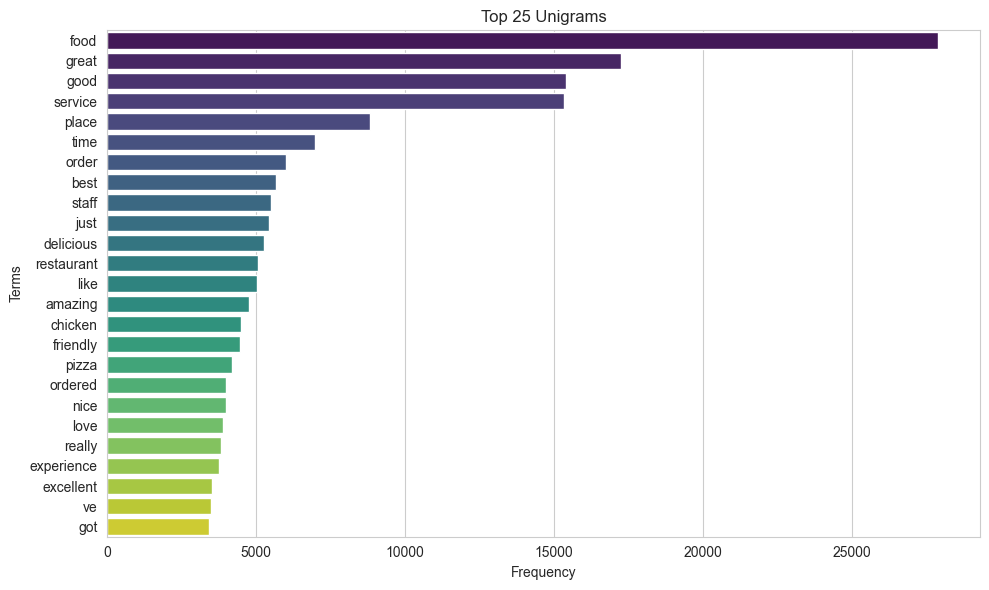

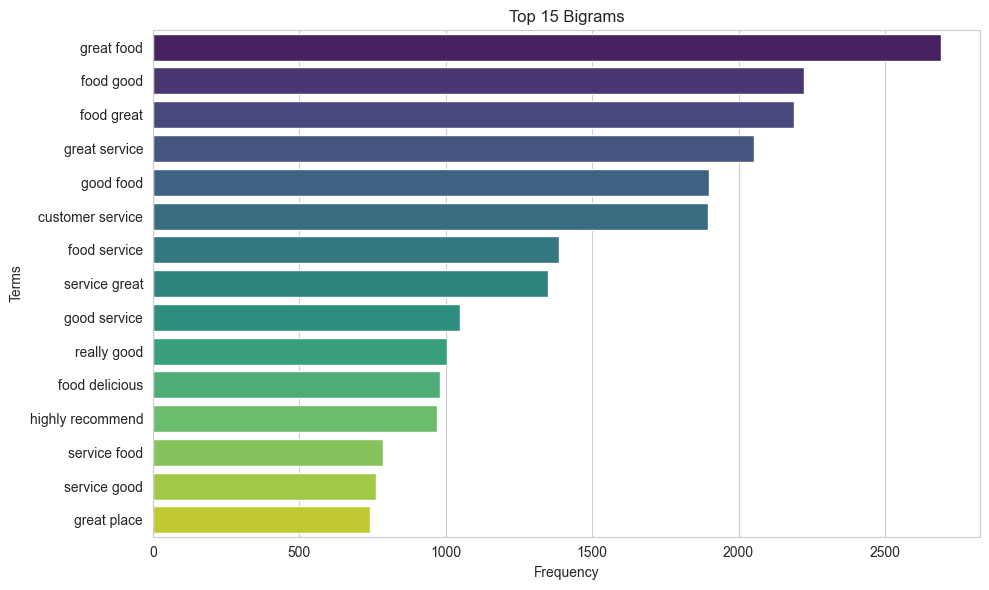

In [23]:
sns.set_style("whitegrid")


def plot_top_ngrams(corpus, n=1, top_k=15, title="Top N-grams"):
    """
    Plots the most frequent n-grams (1 word or 2 words) excluding standard English stopwords.
    """
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english").fit(corpus)

    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    df_ngram = pd.DataFrame(words_freq, columns=["Ngram", "Count"])

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x="Count",
        y="Ngram",
        hue="Ngram",
        data=df_ngram,
        palette="viridis",
        legend=False,
    )

    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Terms")
    plt.tight_layout()
    plt.show()


# Top Unigrams
plot_top_ngrams(atlanta_rest["raw_content"], n=1, top_k=25, title="Top 25 Unigrams")

# Top Bigrams
plot_top_ngrams(atlanta_rest["raw_content"], n=2, title="Top 15 Bigrams")


In [24]:
def plot_cuisine_comparison(df, cat1, cat2, col_name="clean_text"):
    """
    Compares vocabulary of two cuisines using a specified column.
    """
    subset = df[df["categoryName"].isin([cat1, cat2])].copy()

    vec = CountVectorizer(stop_words="english", max_features=20).fit(subset[col_name])

    bag_cat1 = vec.transform(subset[subset["categoryName"] == cat1][col_name]).sum(
        axis=0
    )
    bag_cat2 = vec.transform(subset[subset["categoryName"] == cat2][col_name]).sum(
        axis=0
    )

    words = vec.get_feature_names_out()
    data = pd.DataFrame(
        {
            "word": list(words) * 2,
            "count": bag_cat1.tolist()[0] + bag_cat2.tolist()[0],
            "category": [cat1] * len(words) + [cat2] * len(words),
        }
    )

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=data.sort_values("count", ascending=False),
        x="count",
        y="word",
        hue="category",
        palette="viridis",
    )
    plt.title(f"Vocabulary Comparison: {cat1} vs {cat2}\n(Column: {col_name})")
    plt.xlabel("Frequency")
    plt.ylabel("")
    plt.show()


Stopwords configured: 361 words.


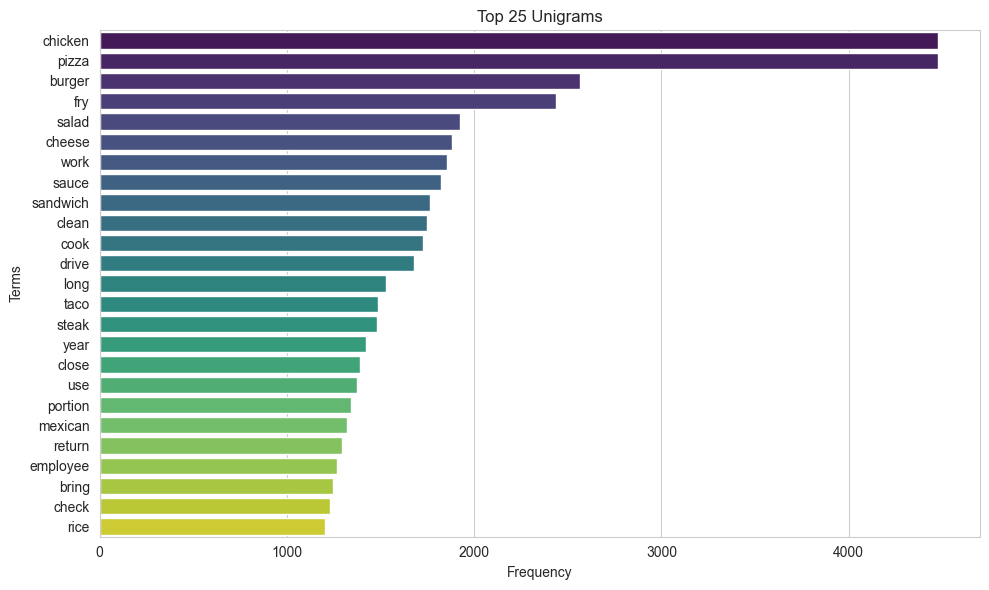

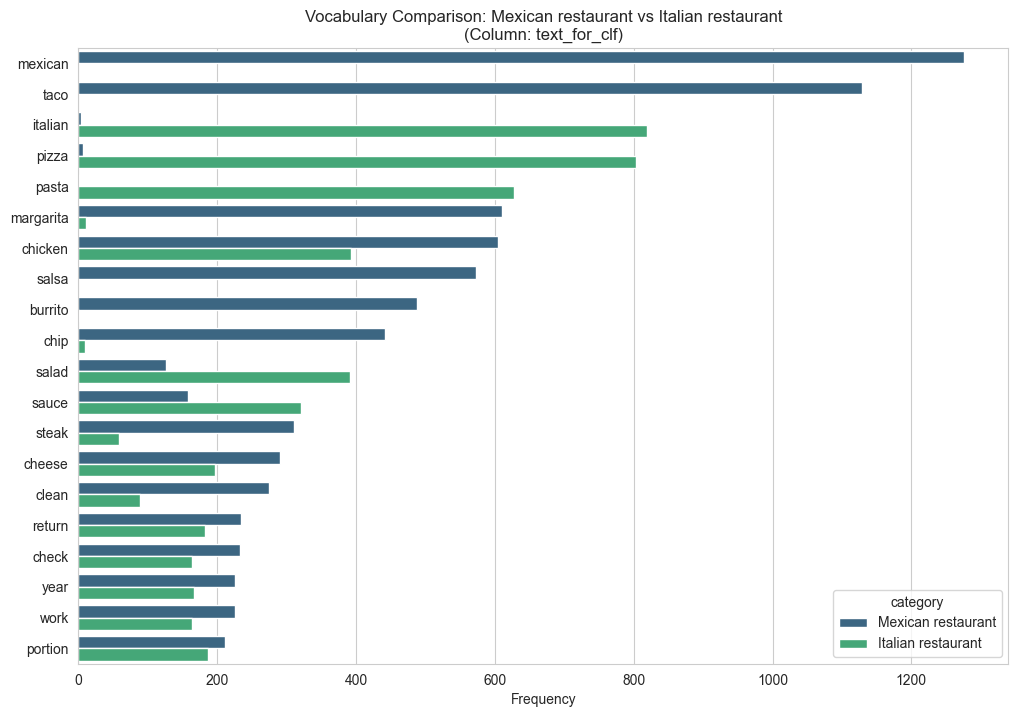

In [25]:
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith("J"):
        return wordnet.ADJ
    elif nltk_tag.startswith("V"):
        return wordnet.VERB
    elif nltk_tag.startswith("N"):
        return wordnet.NOUN
    elif nltk_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


base_stopwords = set(stopwords.words("english"))

domain_specific_list = [
    # Context / Nouns
    "food",
    "restaurant",
    "place",
    "service",
    "staff",
    "manager",
    "server",
    "waiter",
    "waitress",
    "table",
    "menu",
    "order",
    "location",
    "atmosphere",
    "experience",
    "visit",
    "meal",
    "dinner",
    "lunch",
    "breakfast",
    "customer",
    "people",
    "person",
    "family",
    "friend",
    "wife",
    "husband",
    "kid",
    "money",
    "bill",
    "review",
    "minute",
    "hour",
    "time",
    "star",
    "atlanta",
    "area",
    "spot",
    "thing",
    "way",
    "lot",
    "bit",
    "price",
    "quality",
    "bar",
    "drink",
    "option",
    "selection",
    "night",
    "day",
    "today",
    "tonight",
    "side",
    "plate",
    "dish",
    "flavor",
    "taste",
    # Verbs (Lemmas)
    "come",
    "go",
    "get",
    "eat",
    "try",
    "wait",
    "make",
    "want",
    "know",
    "think",
    "take",
    "say",
    "tell",
    "ask",
    "give",
    "look",
    "feel",
    "enjoy",
    "pay",
    "sit",
    "love",
    "like",
    "serve",
    "leave",
    "need",
    "start",
    # Descriptors / Adjectives
    "good",
    "great",
    "nice",
    "best",
    "amazing",
    "delicious",
    "excellent",
    "wonderful",
    "fantastic",
    "perfect",
    "bad",
    "terrible",
    "horrible",
    "fresh",
    "tasty",
    "friendly",
    "awesome",
    "recommend",
    "highly",
    "really",
    "just",
    "definitely",
    "absolutely",
    "pretty",
    "quite",
    "maybe",
    "probably",
    "actually",
    "sure",
    "better",
    "little",
    "big",
    "small",
    "super",
    "happy",
    "new",
    "busy",
    "slow",
    "fast",
    "hot",
    "cold",
    "authentic",
    "attentive",
    "fine",
    "ok",
    "okay",
    "average",
    "huge",
    "worth",
    "amaze",
    "favorite",
    # Grammar/Fragments
    "wa",
    "ha",
    "le",
    "u",
    "ve",
    "ll",
    "re",
    "m",
    "d",
    "s",
    "t",
    "don",
    "did",
    "not",
    "no",
    "yes",
    # new noize words after word cloud
    "one",
    "back",
    "always",
    "well",
    "even",
    "still",
    "never",
    "get",
    "got",
    "way",
    "also",
    "another",
    "us",
    "see",
    "around",
    "thing",
    "think",
    "make",
    "much",
    "go",
    "know",
    "first",
    "last",
    "really",
    "would",
    "could",
    "try",
    "two",
    "told",
    "right",
    "said",
    "back",
    "everything",
    "always",
    "never",
    "thing",
    "nothing",
    "also",
    "look",
    "around",
    "arrive",
]

final_stopwords = base_stopwords.union(domain_specific_list)
print(f"Stopwords configured: {len(final_stopwords)} words.")

lemmatizer = WordNetLemmatizer()


def processing_pipeline_extended(text):
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)

    clean_tokens = []
    clean_tags = []

    for word, tag in tagged_tokens:
        word_lower = word.lower()
        if word_lower.isalpha():
            lemma = lemmatizer.lemmatize(word_lower, get_wordnet_pos(tag))
            if lemma not in final_stopwords and len(lemma) > 2:
                clean_tokens.append(lemma)
                clean_tags.append(tag)

    return " ".join(clean_tokens), clean_tokens, clean_tags


processed_series = atlanta_rest["clean_text"].apply(processing_pipeline_extended)
(
    atlanta_rest["text_for_clf"],
    atlanta_rest["tokens_for_clf"],
    atlanta_rest["pos_tags_for_clf"],
) = zip(*processed_series)
plot_top_ngrams(atlanta_rest["text_for_clf"], n=1, top_k=25, title="Top 25 Unigrams")
plot_cuisine_comparison(
    atlanta_rest, "Mexican restaurant", "Italian restaurant", col_name="text_for_clf"
)

In [29]:
initial_len = len(atlanta_rest)

atlanta_rest = atlanta_rest[atlanta_rest["text_for_clf"].astype(str).str.strip() != ""]

print(
    f"Dropped {initial_len - len(atlanta_rest)} empty rows. Dataset Size: {len(atlanta_rest)}"
)


Dropped 4421 empty rows. Dataset Size: 46226


Generating Word Clouds for 19 categories based on 'text_for_clf'...


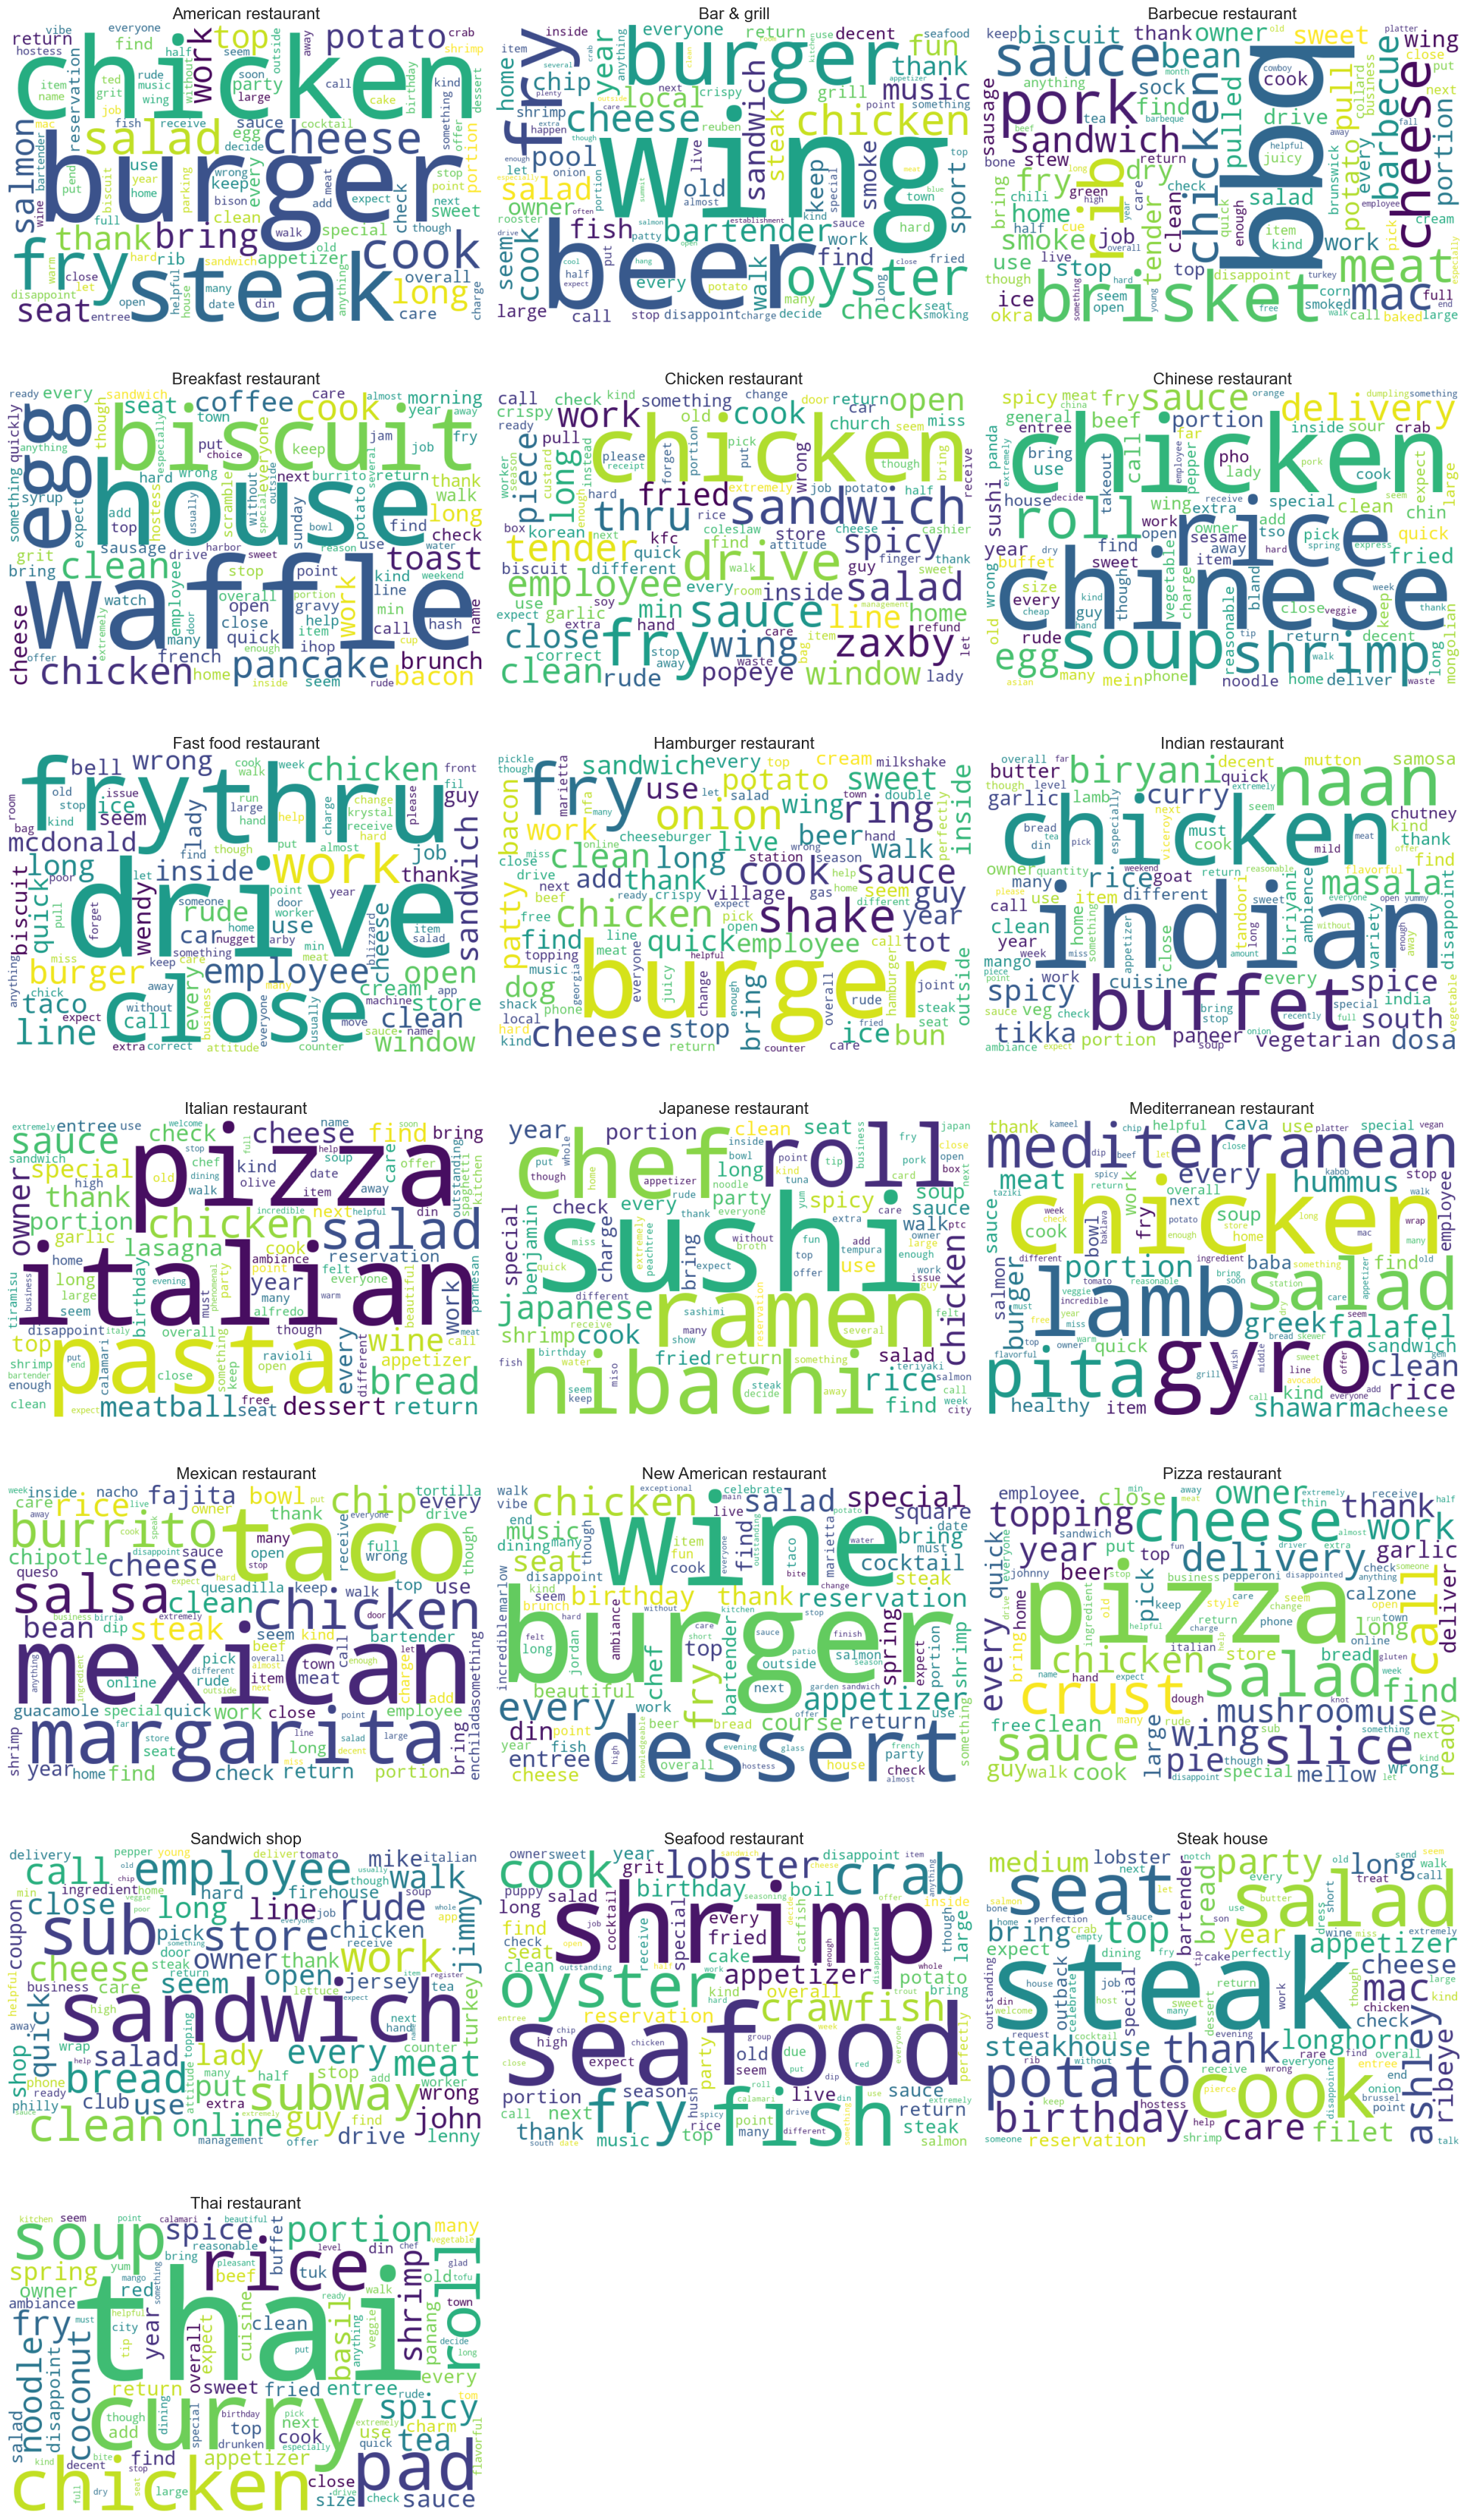

All word clouds saved to 'wordclouds_output/'


In [33]:
texts_by_cat = (
    atlanta_rest.groupby("categoryName")["text_for_clf"]
    .apply(lambda s: " ".join(s))
    .to_dict()
)

# 2. Setup Output
output_dir = "wordclouds_output"
os.makedirs(output_dir, exist_ok=True)

cats = sorted(list(texts_by_cat.keys()))
n = len(cats)
cols = 3
rows = math.ceil(n / cols)

# 3. Generate and Plot
plt.figure(figsize=(20, 5 * rows))

print(f"Generating Word Clouds for {n} categories based on 'text_for_clf'...")

for i, cat in enumerate(cats):
    text = texts_by_cat[cat]

    # Generate WordCloud
    # collocations=False: Don't auto-generate bigrams, show exact tokens we prepared
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        max_words=100,
        collocations=False,
    ).generate(text)

    # Save to file (Sanitize filename)
    filename = cat.replace(" & ", "_").replace(" ", "_") + ".png"
    wc.to_file(os.path.join(output_dir, filename))

    # Plot
    plt.subplot(rows, cols, i + 1)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(cat, fontsize=16)

plt.tight_layout()
plt.show()

print(f"All word clouds saved to '{output_dir}/'")

In [27]:
atlanta_rest.to_csv("data_atlanta/atlanta_cleaned_and_preproccesed.csv", index=False)